In [10]:
# ===== 1. Import libraries =====
from transformers import SegformerImageProcessor, SegformerForSemanticSegmentation
from PIL import Image
import torch
import matplotlib.pyplot as plt
import numpy as np
import requests
from io import BytesIO


In [11]:
# ===== 2. Load the pretrained model and processor =====

model_name = "nvidia/segformer-b0-finetuned-ade-512-512"
processor = SegformerImageProcessor.from_pretrained(model_name)
model = SegformerForSemanticSegmentation.from_pretrained(model_name)

print("Model loaded. Number of classes:", model.config.num_labels)



Loading weights:   0%|          | 0/208 [00:00<?, ?it/s]

Model loaded. Number of classes: 150


In [12]:
# ===== 3. Function to load an image from a URL or local path =====
def load_image(source):
    if source.startswith("http"):
        response = requests.get(source)
        image = Image.open(BytesIO(response.content)).convert("RGB")
    else:
        image = Image.open(source).convert("RGB")
    return image


In [13]:
# ===== 4. Function to run segmentation on one image =====
def segment_image(image):
    # Prepare image for the model
    inputs = processor(images=image, return_tensors="pt")

    # Run the image through the model (no_grad = don't compute gradients, we're not training)
    with torch.no_grad():
        outputs = model(**inputs)

    # outputs.logits has shape [1, num_classes, H, W] — a score for each class at each pixel
    logits = outputs.logits

    # Resize the output back to the original image size
    upsampled_logits = torch.nn.functional.interpolate(
        logits,
        size=image.size[::-1],  # (height, width)
        mode="bilinear",
        align_corners=False
    )

    # Pick the class with the highest score for each pixel -> this is our segmentation mask
    predicted_mask = upsampled_logits.argmax(dim=1)[0].numpy()

    return predicted_mask


In [14]:
# ===== 5. Function to display results =====
def show_segmentation(image, mask, title="Image"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes[0].imshow(image)
    axes[0].set_title(f"Original: {title}")
    axes[0].axis("off")

    axes[1].imshow(mask, cmap="tab20")  # tab20 gives each class a distinct color
    axes[1].set_title("Segmentation Mask")
    axes[1].axis("off")

    plt.tight_layout()
    plt.show()


In [15]:
# ===== 6. Function to list which classes were detected =====
def get_detected_classes(mask):
    unique_ids = np.unique(mask)
    class_names = [model.config.id2label[i] for i in unique_ids]
    return class_names


--- Image 1 ---


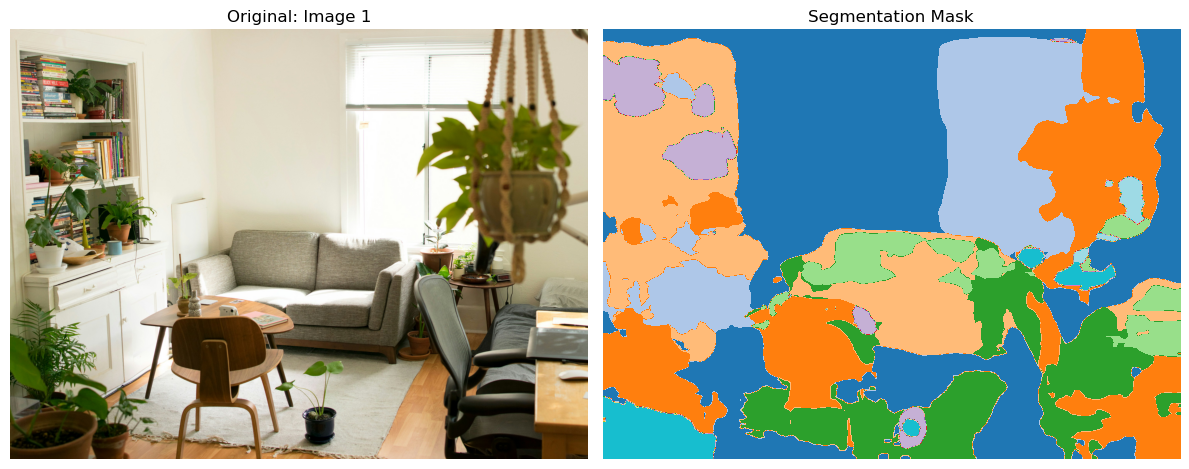

Classes detected: ['wall', 'floor', 'windowpane', 'cabinet', 'table', 'plant', 'curtain', 'chair', 'sofa', 'shelf', 'rug', 'armchair', 'desk', 'lamp', 'cushion', 'bookcase', 'blind', 'coffee table', 'book', 'pot', 'vase']

--- Image 2 ---


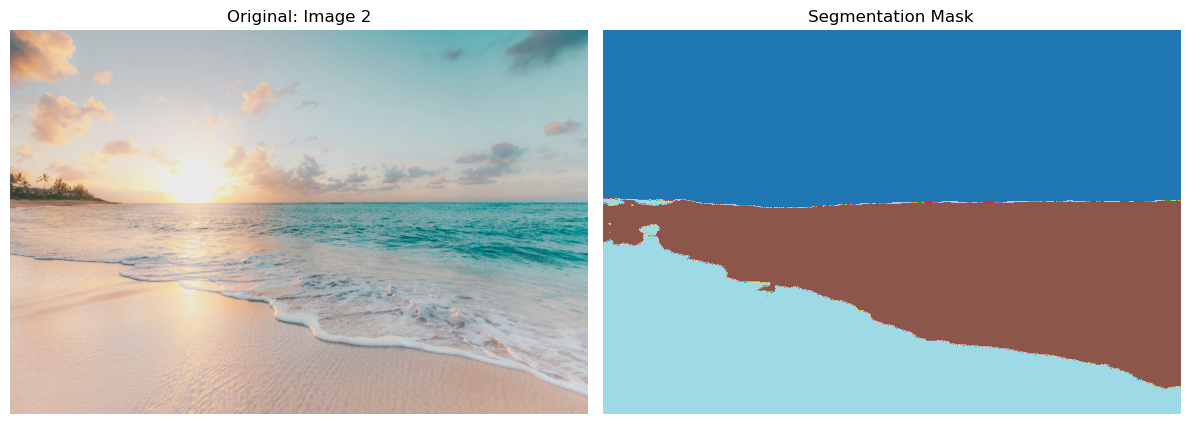

Classes detected: ['sky', 'tree', 'mountain', 'sea', 'sand']

--- Image 3 ---


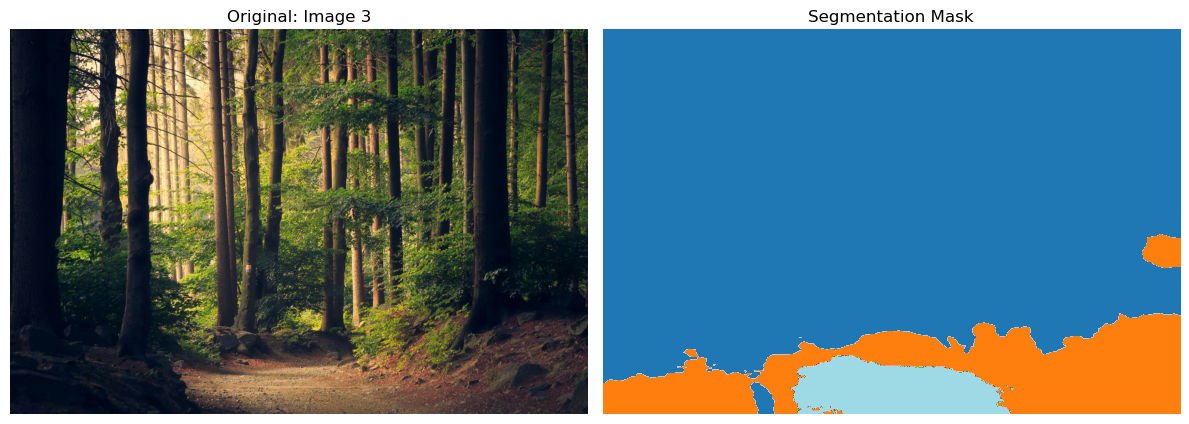

Classes detected: ['tree', 'earth', 'plant', 'dirt track']


In [16]:
# ===== 7. Test with 3+ images =====
image_sources = [
    "https://images.unsplash.com/photo-1502672260266-1c1ef2d93688",  # street/cars
    "https://images.unsplash.com/photo-1507525428034-b723cf961d3e",  # people/bench
    "https://images.unsplash.com/photo-1441974231531-c6227db76b6e",  # forest/nature
]

for i, src in enumerate(image_sources):
    print(f"\n--- Image {i+1} ---")
    img = load_image(src)
    mask = segment_image(img)
    show_segmentation(img, mask, title=f"Image {i+1}")

    classes_found = get_detected_classes(mask)
    print("Classes detected:", classes_found)